In [1]:
print("ML Regression Project Started!")


ML Regression Project Started!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("salary_data.csv")

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.shape


df.info()


df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
df.duplicated().sum()
df.isnull().sum().sum()

np.int64(0)

In [13]:
df[
    [
        "Age",
        "TotalWorkingYears",
        "YearsAtCompany",
        "JobLevel",
        "YearsInCurrentRole",
        "MonthlyIncome"
    ]
].describe()

,Age,TotalWorkingYears,YearsAtCompany,JobLevel,YearsInCurrentRole,MonthlyIncome
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,11.279592,7.008163,2.063946,4.229252,6502.931293
std,9.135373,7.780782,6.126525,1.106940,3.623137,4707.956783
min,18.000000,0.000000,0.000000,1.000000,0.000000,1009.000000
25%,30.000000,6.000000,3.000000,1.000000,2.000000,2911.000000
50%,36.000000,10.000000,5.000000,2.000000,3.000000,4919.000000
75%,43.000000,15.000000,9.000000,3.000000,7.000000,8379.000000
max,60.000000,40.000000,40.000000,5.000000,18.000000,19999.000000


In [14]:
missing_values=df.isnull().sum()
missing_values[missing_values>0]

Series([], dtype: int64)

In [15]:
missing_percentage=df.isnull().sum() / len(df) *100
missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [16]:
df_clean=df.copy()
print("working data created")

working data created


In [17]:
df_clean.duplicated().sum()

np.int64(0)

In [18]:
df_clean=df_clean.drop_duplicates()

In [19]:
df_clean.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [20]:
df_clean["Age"].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

In [21]:
df_clean["Age"].min()

np.int64(18)

In [22]:
df_clean["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [23]:
df_clean["Gender"].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [24]:
Q1=df_clean["MonthlyIncome"].quantile(0.25)
Q3=df_clean["MonthlyIncome"].quantile(0.75)

IQR=Q3-Q1

print("Q3",Q3)
print("Q1", Q1)
print("IQR",IQR)

Q3 8379.0
Q1 2911.0
IQR 5468.0


In [25]:
lower_bound=Q1 - 1.5 * IQR
upper_bound=Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -5291.0
Upper bound: 16581.0


In [26]:
outliers=df_clean[
    (df_clean["MonthlyIncome"] < lower_bound ) |
    (df_clean["MonthlyIncome"] > upper_bound)
]

outliers

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
25,53,No,Travel_Rarely,1282,Research & Development,5,3,Other,1,32,...,4,80,1,26,3,2,14,13,4,8
29,46,No,Travel_Rarely,705,Sales,2,4,Marketing,1,38,...,4,80,0,22,2,2,2,2,2,1
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,29,2,2,27,3,13,8
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,1,140,...,4,80,1,30,3,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,58,No,Travel_Rarely,605,Sales,21,3,Life Sciences,1,1938,...,3,80,1,29,2,2,1,0,0,0
1377,49,No,Travel_Frequently,1064,Research & Development,2,1,Life Sciences,1,1941,...,4,80,0,28,3,3,5,4,4,3
1401,55,No,Travel_Rarely,189,Human Resources,26,4,Human Resources,1,1973,...,1,80,1,35,0,3,10,9,1,4
1437,39,No,Non-Travel,105,Research & Development,9,3,Life Sciences,1,2022,...,3,80,0,21,3,2,6,0,1,3


In [27]:
len(outliers)

114

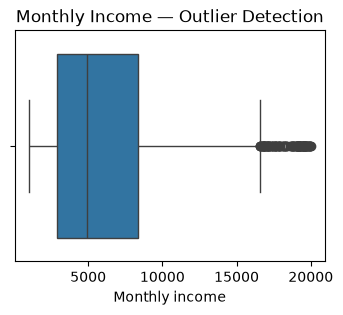

In [28]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df_clean["MonthlyIncome"])

plt.title("Monthly Income — Outlier Detection")
plt.xlabel("Monthly income")

plt.show()

In [29]:
numerical_columns=df_clean.select_dtypes(include=np.number).columns
print(numerical_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


In [30]:
for column in numerical_columns:
  Q1=df_clean[column].quantile(0.25)
  Q3=df_clean[column].quantile(0.75)
  IQR= Q3 -  Q1

  lower=Q1 - 1.5 * IQR
  upper=Q3 + 1.5 * IQR

  outliers = df_clean[
        (df_clean[column] < lower) |
        (df_clean[column] > upper)
    ]

  print(column, "→", len(outliers), "potential outliers")

Age → 0 potential outliers
DailyRate → 0 potential outliers
DistanceFromHome → 0 potential outliers
Education → 0 potential outliers
EmployeeCount → 0 potential outliers
EmployeeNumber → 0 potential outliers
EnvironmentSatisfaction → 0 potential outliers
HourlyRate → 0 potential outliers
JobInvolvement → 0 potential outliers
JobLevel → 0 potential outliers
JobSatisfaction → 0 potential outliers
MonthlyIncome → 114 potential outliers
MonthlyRate → 0 potential outliers
NumCompaniesWorked → 52 potential outliers
PercentSalaryHike → 0 potential outliers
PerformanceRating → 226 potential outliers
RelationshipSatisfaction → 0 potential outliers
StandardHours → 0 potential outliers
StockOptionLevel → 85 potential outliers
TotalWorkingYears → 63 potential outliers
TrainingTimesLastYear → 238 potential outliers
WorkLifeBalance → 0 potential outliers
YearsAtCompany → 104 potential outliers
YearsInCurrentRole → 21 potential outliers
YearsSinceLastPromotion → 107 potential outliers
YearsWithCurrMa

In [31]:
len(outliers)

14

In [32]:
print("Rows:", df_clean.shape[0])
print("colums:", df_clean.shape[1])

print("total missing values:", df_clean.isnull().sum().sum())

print("total duplicate values:",df_clean.duplicated().sum())

Rows: 1470
colums: 35
total missing values: 0
total duplicate values: 0


In [33]:
numerical_columns=df_clean.select_dtypes(include=np.number).columns
print(numerical_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


In [34]:
correlation = df_clean[numerical_columns].corr()

salary_correlation=correlation["MonthlyIncome"].sort_values(ascending=False)

print(salary_correlation)

MonthlyIncome               1.000000
JobLevel                    0.950300
TotalWorkingYears           0.772893
YearsAtCompany              0.514285
Age                         0.497855
YearsInCurrentRole          0.363818
YearsSinceLastPromotion     0.344978
YearsWithCurrManager        0.344079
NumCompaniesWorked          0.149515
Education                   0.094961
MonthlyRate                 0.034814
WorkLifeBalance             0.030683
RelationshipSatisfaction    0.025873
DailyRate                   0.007707
StockOptionLevel            0.005408
EnvironmentSatisfaction    -0.006259
JobSatisfaction            -0.007157
EmployeeNumber             -0.014829
JobInvolvement             -0.015271
HourlyRate                 -0.015794
DistanceFromHome           -0.017014
PerformanceRating          -0.017120
TrainingTimesLastYear      -0.021736
PercentSalaryHike          -0.027269
EmployeeCount                    NaN
StandardHours                    NaN
Name: MonthlyIncome, dtype: float64


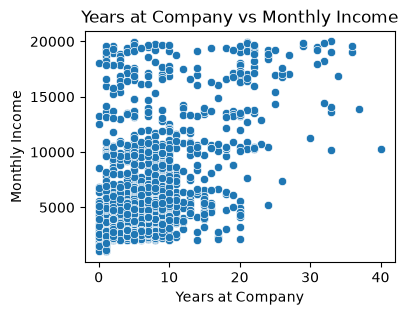

In [35]:
plt.figure(figsize=(4,3))

sns.scatterplot(
    x=df_clean["YearsAtCompany"],
    y=df_clean["MonthlyIncome"]
)
plt.title("Years at Company vs Monthly Income")
plt.xlabel("Years at Company")
plt.ylabel("Monthly Income")

plt.show()

In [36]:
X = df_clean[["YearsAtCompany"]]
y = df_clean["MonthlyIncome"]

In [37]:
#Train and Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10
)

In [38]:
#Train Linear regression

from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)
print(y_pred)


print("Aactual:",y_test.values[:10])
print("predicted:",y_pred[:10])

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

[ 5344.81079126  4148.49128525  5743.58395993  6541.13029727
 11725.18148998  4148.49128525  6939.90346594  9731.31564663
  4148.49128525  9332.54247796  4946.03762259  7737.44980328
  5743.58395993  3749.71811658  6939.90346594 19700.64486338
  7338.67663461  5743.58395993  5743.58395993  6541.13029727
  4148.49128525  7737.44980328  7338.67663461  5743.58395993
  7737.44980328 10927.63515264  5344.81079126  7737.44980328
  7737.44980328  4946.03762259  7737.44980328  5344.81079126
 10927.63515264  4547.26445392  7737.44980328  6541.13029727
  5344.81079126  5743.58395993 10528.86198397  4547.26445392
  6541.13029727  7737.44980328  7737.44980328  5743.58395993
  7737.44980328  4148.49128525  8136.22297195  8136.22297195
 15712.91317668  5344.81079126  4148.49128525  7737.44980328
  5743.58395993  7737.44980328  5743.58395993  4547.26445392
  4946.03762259  7338.67663461  5743.58395993  6541.13029727
  8136.22297195  4148.49128525  4946.03762259  5344.81079126
  4547.26445392  4148.49

In [39]:
#caluculating MAE,MSE,R2
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae=mean_absolute_error(y_test,y_pred)

mse=mean_squared_error(y_test,y_pred)

r2=r2_score(y_test,y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 2843.673345446478
MSE: 15172855.752561435
R2: 0.2495006966075919


In [40]:
#predict a new employee

new_employee=pd.DataFrame({
    "YearsAtCompany": [7.5]
})

predicted_income=model.predict(new_employee)

print("Predicted Monthly Income:", predicted_income[0])

Predicted Monthly Income: 6740.516881606377


In [41]:
#create multiple features

X=df_clean[
    [
        "Age",
        "TotalWorkingYears",
        "YearsAtCompany",
        "JobLevel",
        "YearsInCurrentRole"
    ]
]

y = df_clean["MonthlyIncome"]

In [42]:
#split again

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Train
model_multiple = LinearRegression()

model_multiple.fit(X_train, y_train)

#predict
y_pred_multiple = model_multiple.predict(X_test)

#Evalute multiple regression

mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("MAE:", mae_multiple)
print("MSE:", mse_multiple)
print("R²:", r2_multiple)


# Predict a new employee

new_employee = pd.DataFrame([{
    "Age": 28,
    "TotalWorkingYears": 6,
    "YearsAtCompany": 5,
    "JobLevel": 2,
    "YearsInCurrentRole": 3
}])

new_employee = new_employee[X.columns]

# Predict
predicted_income_multiple = model_multiple.predict(new_employee)

print("Predicted Monthly Income:", predicted_income_multiple[0])

MAE: 1165.2141614005795
MSE: 2287430.3327883487
R²: 0.8953380205543623
Predicted Monthly Income: 6097.653040639255


In [43]:
#polynomial regression

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

#split

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

#train
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train_poly)

#predict

y_pred_poly = poly_model.predict(X_test_poly)

#evalute

mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print("MAE:", mae_poly)
print("MSE:", mse_poly)
print("R²:", r2_poly)

# Predict a new employee

new_employee = pd.DataFrame([{
    "Age": 28,
    "JobLevel": 2,
    "TotalWorkingYears": 6,
    "YearsInCurrentRole": 3,
    "YearsAtCompany": 5
}])

new_employee = new_employee[X.columns]

new_employee_poly = poly.transform(new_employee)

predicted_income_poly = poly_model.predict(new_employee_poly)

print("Predicted Monthly Income:", predicted_income_poly[0])

MAE: 1038.2904466173961
MSE: 1958583.1827166637
R²: 0.9103845088203478
Predicted Monthly Income: 5526.727423603087


In [44]:
#Ridge Regression

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("R²:", r2_ridge)

MAE: 1164.6175529019793
MSE: 2286457.8233017884
R²: 0.8953825179829545


In [45]:
#lasso Regresion

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("R²:", r2_lasso)

MAE: 1165.1960665641489
MSE: 2287405.258633981
R²: 0.8953391678289225


In [46]:
results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        mae,
        mae_multiple,
        mae_poly,
        mae_ridge,
        mae_lasso
    ],
    "MSE": [
        mse,
        mse_multiple,
        mse_poly,
        mse_ridge,
        mse_lasso
    ],
    "R2": [
        r2,
        r2_multiple,
        r2_poly,
        r2_ridge,
        r2_lasso
    ]
})

results

,Model,MAE,MSE,R2
0,Simple Linear Regression,2843.673345,1.517286e+07,0.249501
1,Multiple Linear Regression,1165.214161,2.287430e+06,0.895338
2,Polynomial Regression,1038.290447,1.958583e+06,0.910385
3,Ridge Regression,1164.617553,2.286458e+06,0.895383
4,Lasso Regression,1165.196067,2.287405e+06,0.895339
